# Paper task visualization and training (Orhan & Ma Kalman RNN)

Interactive companion to `paper_pytorch`: sample the Kalman Filtering Task and visualize how Target, Gain, Expected rate, and population spikes form the RNN input, then train the RNN and evaluate its checkpoint.

Domain terms: **Trial**, **Batch**, **Batch internals**, **Target**, **Gain**, **Expected rate**, **Population count**, **Instantaneous population estimate**, **Opt mean**, **Opt variance**, **Training loss**, **Fractional RMSE** — see `CONTEXT.md`.

On Google Colab, run the setup cell below once before the imports.

In [12]:
!git clone https://github.com/jgrk28/kalnet.git
%cd kalnet
%pip install -e .

Cloning into 'kalnet'...
remote: Enumerating objects: 69, done.
remote: Counting objects: 100% (69/69), done.
remote: Compressing objects: 100% (63/63), done.
remote: Total 69 (delta 33), reused 25 (delta 6), pack-reused 0 (from 0)
Receiving objects: 100% (69/69), 1.99 MiB | 4.60 MiB/s, done.
Resolving deltas: 100% (33/33), done.
/content/kalnet
Obtaining file:///content/kalnet
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Installing backend dependencies ... done
  Preparing editable metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 109.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 134.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 913.3/913.3 kB 61.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.5/77.5 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.8/59

In [28]:
import matplotlib.pyplot as plt
import numpy as np

from paper_pytorch.task import KalmanFilteringTask

plt.rcParams.update(
    {
        "figure.figsize": (8, 3.5),
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": False,
    }
)

## Sample and visualize the task

Each **Trial** is a length-`stim_dur` sequence. The hidden **Target** `s` and **Gain** determine each neuron's **Expected rate**; Poisson sampling then produces the population spike counts that are the RNN's only input. Optional **Batch internals** let us visualize that generation process and the optimal Kalman filter's estimate.

In [29]:
task = KalmanFilteringTask(
    batch_size=8,
    n_in=50,
    stim_dur=25,
    tr_cond="all_gains",
    seed=0,
)
batch = task.sample(include_internals=True)
assert batch.internals is not None
print(
    f"input {batch.input.shape}, target {batch.target.shape}, "
    f"opt_mean {batch.opt_mean.shape}"
)

trial_idx = 0
t = np.arange(batch.target.shape[1])
phi = task.phi
s = batch.target[trial_idx, :, 0]
m = batch.opt_mean[trial_idx, :, 0]
spikes = batch.input[trial_idx]  # (T, n_in)
gain = batch.internals.gain[trial_idx, :, 0]
expected_rate = batch.internals.expected_rate[trial_idx]
opt_var = batch.internals.opt_var[trial_idx, :, 0]

population_count = spikes.sum(axis=1)
weighted_sum = spikes @ phi
population_estimate = np.full_like(s, np.nan)
np.divide(
    weighted_sum,
    population_count,
    out=population_estimate,
    where=population_count > 0,
)

# Single-timestep likelihood width for Gaussian tuning + Poisson noise:
# var = sigtc_sq / (total spike count). Shrinks as more spikes arrive.
population_sd = np.full_like(s, np.nan)
np.divide(
    task.sigtc_sq,
    population_count,
    out=population_sd,
    where=population_count > 0,
)
population_sd = np.sqrt(population_sd)

selected_times = [
    int(np.argmin(gain)),
    int(np.argmin(np.abs(gain - np.median(gain)))),
    int(np.argmax(gain)),
]
selected_labels = ["lowest", "median", "highest"]

input (8, 25, 50), target (8, 25, 1), opt_mean (8, 25, 1)


### A. How Target and Gain create the RNN input

At each selected timestep, Target `s_t` centers a Gaussian profile over neurons' preferred stimuli and Gain `g_t` scales it. The profile is the Expected rate; the bars are one Poisson sample from it.

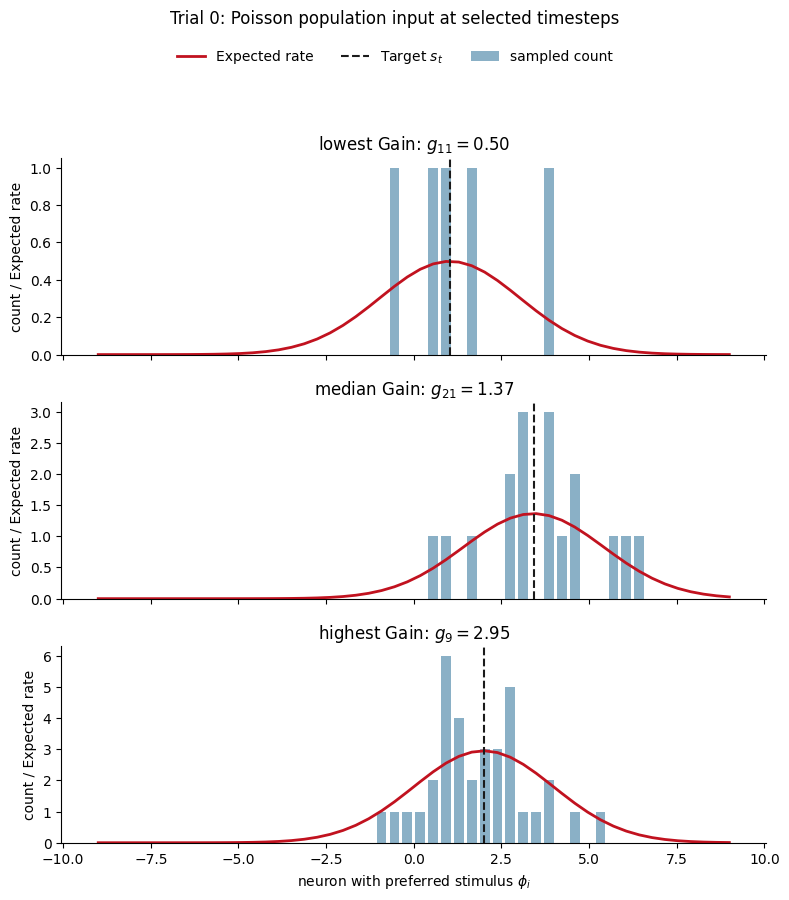

In [30]:
fig, axes = plt.subplots(3, 1, figsize=(8, 9), sharex=True)
for ax, tt, gain_label in zip(axes, selected_times, selected_labels):
    ax.bar(
        phi,
        spikes[tt],
        width=0.28,
        color="#2a6f97",
        alpha=0.55,
        label="sampled count",
    )
    ax.plot(phi, expected_rate[tt], color="#c1121f", lw=2, label="Expected rate")
    ax.axvline(s[tt], color="#1a1a1a", lw=1.5, ls="--", label="Target $s_t$")
    ax.set_title(f"{gain_label} Gain: $g_{{{tt}}}={gain[tt]:.2f}$")
    ax.set_ylabel("count / Expected rate")

axes[-1].set_xlabel("neuron with preferred stimulus $\\phi_i$")
handles, labels = axes[-1].get_legend_handles_labels()
fig.suptitle(
    f"Trial {trial_idx}: Poisson population input at selected timesteps",
    y=0.995,
)
fig.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.965),
    ncol=3,
    frameon=False,
)
fig.tight_layout(rect=(0, 0, 1, 0.91))
plt.show()

### B. Full-Trial population activity

The Expected-rate heatmap shows the hidden generative profile. The spike-count heatmap shows the sampled input that the RNN actually receives.

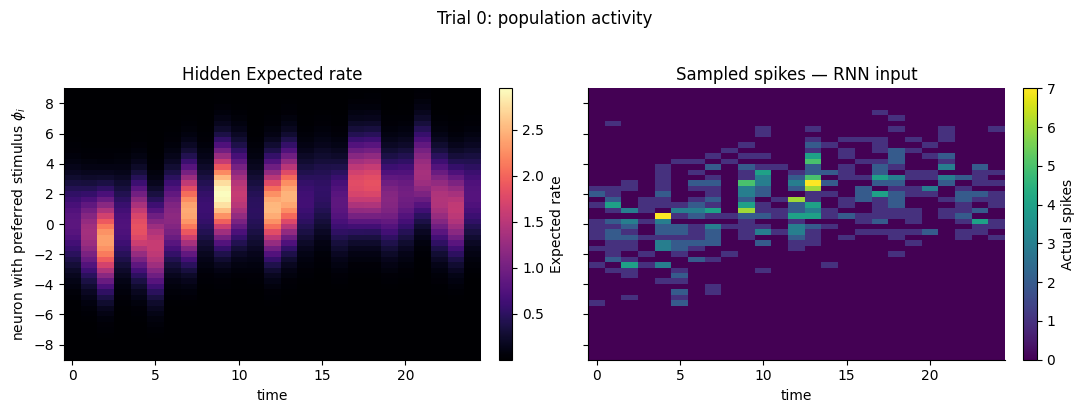

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharex=True, sharey=True)
extent = (-0.5, len(t) - 0.5, phi[0], phi[-1])

rate_im = axes[0].imshow(
    expected_rate.T,
    aspect="auto",
    origin="lower",
    interpolation="nearest",
    cmap="magma",
    extent=extent,
)
spike_im = axes[1].imshow(
    spikes.T,
    aspect="auto",
    origin="lower",
    interpolation="nearest",
    cmap="viridis",
    extent=extent,
)

axes[0].set_title("Hidden Expected rate")
axes[1].set_title("Sampled spikes — RNN input")
for ax in axes:
    ax.set_xlabel("time")
axes[0].set_ylabel("neuron with preferred stimulus $\\phi_i$")
fig.colorbar(rate_im, ax=axes[0], fraction=0.046, pad=0.04, label="Expected rate")
fig.colorbar(spike_im, ax=axes[1], fraction=0.046, pad=0.04, label="Actual spikes")
fig.suptitle(f"Trial {trial_idx}: population activity", y=1.02)
fig.tight_layout()
plt.show()

### C. What the RNN can infer from its input

Population count is an observable proxy for the hidden Gain. The Instantaneous population estimate summarizes the stimulus location encoded by the current spikes without using temporal history.

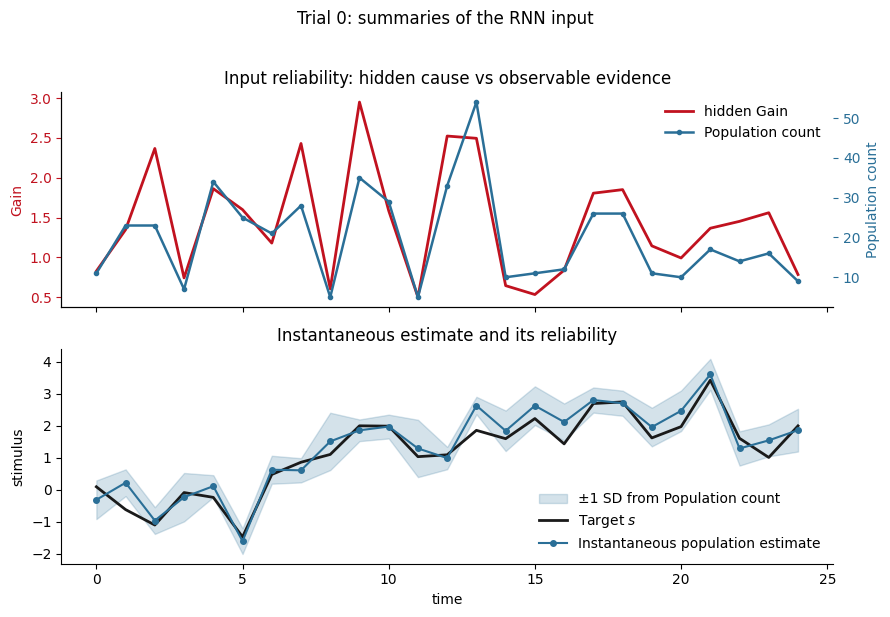

In [32]:
fig, axes = plt.subplots(2, 1, figsize=(9, 6), sharex=True)

count_ax = axes[0].twinx()
gain_line = axes[0].plot(t, gain, color="#c1121f", lw=2, label="hidden Gain")
count_line = count_ax.plot(
    t,
    population_count,
    color="#2a6f97",
    lw=1.8,
    marker="o",
    ms=3,
    label="Population count",
)
axes[0].set_ylabel("Gain", color="#c1121f")
count_ax.set_ylabel("Population count", color="#2a6f97")
axes[0].tick_params(axis="y", colors="#c1121f")
count_ax.tick_params(axis="y", colors="#2a6f97")
axes[0].set_title("Input reliability: hidden cause vs observable evidence")
axes[0].legend(gain_line + count_line, [line.get_label() for line in gain_line + count_line], frameon=False)

axes[1].fill_between(
    t,
    population_estimate - population_sd,
    population_estimate + population_sd,
    color="#2a6f97",
    alpha=0.2,
    label="±1 SD from Population count",
)
axes[1].plot(t, s, color="#1a1a1a", lw=2, label="Target $s$")
axes[1].plot(
    t,
    population_estimate,
    color="#2a6f97",
    lw=1.5,
    marker="o",
    ms=4,
    label="Instantaneous population estimate",
)
axes[1].set_xlabel("time")
axes[1].set_ylabel("stimulus")
axes[1].set_title("Instantaneous estimate and its reliability")
axes[1].legend(frameon=False)

fig.suptitle(f"Trial {trial_idx}: summaries of the RNN input", y=1.02)
fig.tight_layout()
plt.show()

### D. Instantaneous estimate vs optimal estimate

The Instantaneous population estimate uses only the spikes at the current timestep. The Opt mean recursively combines that evidence with prior timesteps. Both are overlaid with the true Target; shaded regions show ±1 standard deviation.

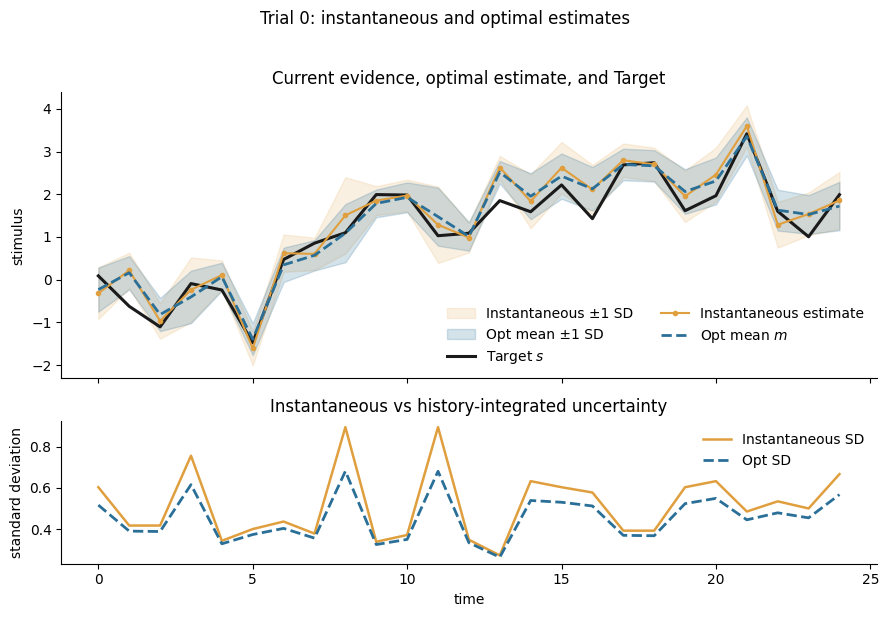

In [33]:
opt_sd = np.sqrt(opt_var)
fig, axes = plt.subplots(
    2,
    1,
    figsize=(9, 6),
    sharex=True,
    gridspec_kw={"height_ratios": [2, 1]},
)

axes[0].fill_between(
    t,
    population_estimate - population_sd,
    population_estimate + population_sd,
    color="#e09f3e",
    alpha=0.15,
    label="Instantaneous ±1 SD",
)
axes[0].fill_between(
    t,
    m - opt_sd,
    m + opt_sd,
    color="#2a6f97",
    alpha=0.2,
    label="Opt mean ±1 SD",
)
axes[0].plot(t, s, color="#1a1a1a", lw=2.2, label="Target $s$")
axes[0].plot(
    t,
    population_estimate,
    color="#e09f3e",
    lw=1.5,
    marker="o",
    ms=3,
    label="Instantaneous estimate",
)
axes[0].plot(t, m, color="#2a6f97", lw=2, ls="--", label="Opt mean $m$")
axes[0].set_ylabel("stimulus")
axes[0].set_title("Current evidence, optimal estimate, and Target")
axes[0].legend(frameon=False, ncols=2)

axes[1].plot(t, population_sd, color="#e09f3e", lw=1.8, label="Instantaneous SD")
axes[1].plot(t, opt_sd, color="#2a6f97", lw=2, ls="--", label="Opt SD")
axes[1].set_xlabel("time")
axes[1].set_ylabel("standard deviation")
axes[1].set_title("Instantaneous vs history-integrated uncertainty")
axes[1].legend(frameon=False)

fig.suptitle(f"Trial {trial_idx}: instantaneous and optimal estimates", y=1.02)
fig.tight_layout()
plt.show()

## Train and visualize the network

Adam minimizes **Training loss** (final-timestep MSE vs Target). Logs use **Fractional RMSE** vs Opt mean every `log_every` batches. Run once, then skip this cell and load the checkpoint below.

Defaults match the paper port: 50 001 train batches, batch size 10, lr `2e-4`.

In [34]:
from pathlib import Path
import torch

from paper_pytorch.train import (
    DEFAULT_CHECKPOINT,
    batch_to_tensors,
    load_checkpoint,
    train,
)

REPO_ROOT = Path.cwd().resolve()
if REPO_ROOT.name == "notebooks":
    REPO_ROOT = REPO_ROOT.parent

SEED = 0
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
CHECKPOINT = REPO_ROOT / DEFAULT_CHECKPOINT
print(f"device={DEVICE}, checkpoint={CHECKPOINT}")
if DEVICE == "cpu":
    print("Note: CUDA unavailable here; full 50k run will be slower on CPU.")

device=cuda, checkpoint=/content/kalnet/paper_pytorch/kalman_checkpoints/kf_allgains.pt


In [35]:
# Skip if CHECKPOINT already exists and you only want to plot.
result = train(
    max_iter=50_001,
    test_iter=2_501,
    batch_size=10,
    log_every=500,
    lr=2e-4,
    tr_cond="all_gains",
    test_cond="all_gains",
    seed=SEED,
    device=DEVICE,
    save_path=CHECKPOINT,
)
print(
    f"test Fractional RMSE={result['frac_rmse_test']:.4f}, "
    f"saved {CHECKPOINT.resolve()}"
)

Batch #0; Frac. RMSE: 5.924677; Opt. RMSE: 0.466650; Net. RMSE: 3.231403
Batch #500; Frac. RMSE: 1.551177; Opt. RMSE: 0.447285; Net. RMSE: 1.141104
Batch #1000; Frac. RMSE: 0.680670; Opt. RMSE: 0.465338; Net. RMSE: 0.782081
Batch #1500; Frac. RMSE: 0.611010; Opt. RMSE: 0.444635; Net. RMSE: 0.716311
Batch #2000; Frac. RMSE: 0.477334; Opt. RMSE: 0.439212; Net. RMSE: 0.648863
Batch #2500; Frac. RMSE: 0.390444; Opt. RMSE: 0.456974; Net. RMSE: 0.635397
Batch #3000; Frac. RMSE: 0.336657; Opt. RMSE: 0.451116; Net. RMSE: 0.602988
Batch #3500; Frac. RMSE: 0.334665; Opt. RMSE: 0.453975; Net. RMSE: 0.605904
Batch #4000; Frac. RMSE: 0.290915; Opt. RMSE: 0.452766; Net. RMSE: 0.584482
Batch #4500; Frac. RMSE: 0.263864; Opt. RMSE: 0.459704; Net. RMSE: 0.581004
Batch #5000; Frac. RMSE: 0.262695; Opt. RMSE: 0.456084; Net. RMSE: 0.575895
Batch #5500; Frac. RMSE: 0.240962; Opt. RMSE: 0.452246; Net. RMSE: 0.561220
Batch #6000; Frac. RMSE: 0.224075; Opt. RMSE: 0.465443; Net. RMSE: 0.569737
Batch #6500; Fra

## Load checkpoint and visualize training

### Fractional RMSE learning curve

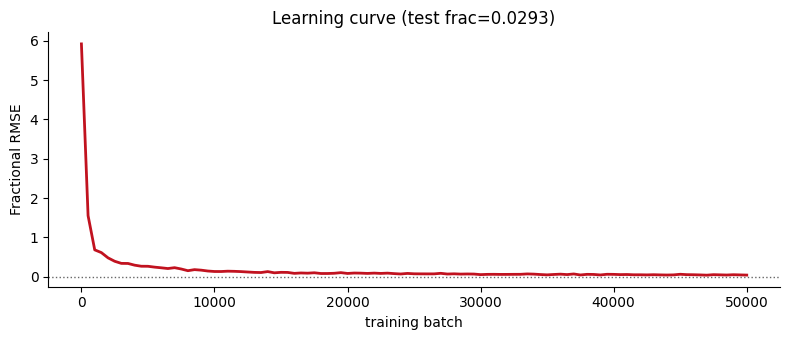

{'n_in': 50,
 'n_hid': 200,
 'stim_dur': 25,
 'batch_size': 10,
 'lr': 0.0002,
 'tr_cond': 'all_gains',
 'test_cond': 'all_gains',
 'seed': 0,
 'log_every': 500,
 'max_iter': 50001}

In [36]:
loaded = load_checkpoint(CHECKPOINT, device=DEVICE)
model = loaded["model"]
cfg = loaded["config"]
frac = loaded["frac_rmse_vec"]
log_every = cfg.get("log_every", 500)
batches = np.arange(len(frac)) * log_every

fig, ax = plt.subplots()
ax.plot(batches, frac, color="#c1121f", lw=2)
ax.axhline(0.0, color="#666666", lw=1, ls=":")
ax.set_xlabel("training batch")
ax.set_ylabel("Fractional RMSE")
ax.set_title(
    f"Learning curve (test frac={loaded['frac_rmse_test']:.4f})"
)
fig.tight_layout()
plt.show()
cfg

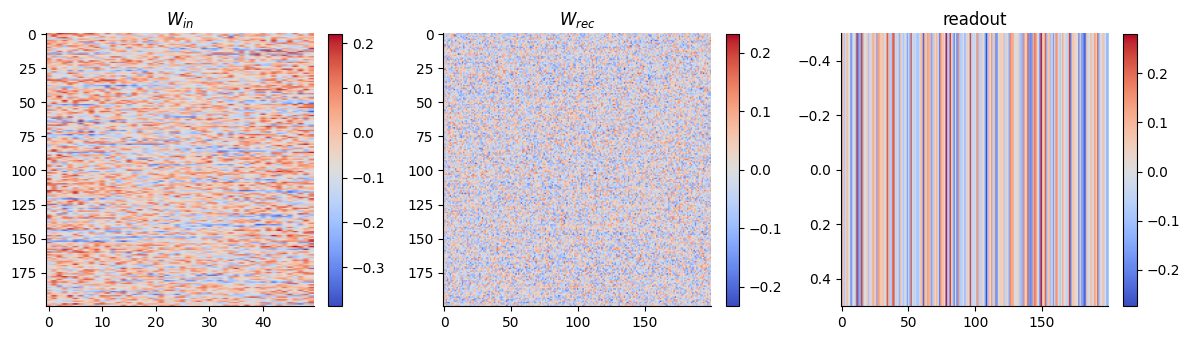

In [37]:
W_in = model.W_in.weight.detach().cpu().numpy()      # (n_hid, n_in)
W_rec = model.W_rec.weight.detach().cpu().numpy()    # (n_hid, n_hid)
w_out = model.readout.weight.detach().cpu().numpy()  # (1, n_hid)
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
for ax, mat, title in zip(
    axes,
    [W_in, W_rec, w_out],
    ["$W_{in}$", "$W_{rec}$", "readout"],
):
    im = ax.imshow(mat, aspect="auto", cmap="coolwarm")
    ax.set_title(title)
    fig.colorbar(im, ax=ax, fraction=0.046)
fig.tight_layout()
plt.show()

Collect data from the network to compare to ground truth

In [49]:
%cd paper_pytorch/
%run collect_data_rnn.py

/content/kalnet/paper_pytorch
Loaded trained network.
Saved kf_dataset.pt
  train:    r_hid torch.Size([5000, 25, 200])
  test:     r_hid torch.Size([2000, 25, 200])


Testing network performance

In [52]:
import torch
from model import KalmanRNN

In [54]:
checkpoint = torch.load("kalman_checkpoints/kf_allgains.pt", map_location="cpu", weights_only=False)
net = KalmanRNN(n_in=checkpoint["config"]["n_in"], n_hid=checkpoint["config"]["n_hid"], n_out=1)
net.load_state_dict(checkpoint["state_dict"])
net.eval()

test_task = KalmanFilteringTask(batch_size=2000, tr_cond="all_gains", seed=999)
batch = test_task.sample(include_internals=True)

x = torch.from_numpy(batch.input)
y_true = torch.from_numpy(batch.target)
y_opt = torch.from_numpy(batch.opt_mean)

with torch.no_grad():
    y_hat = net(x)

rmse_net = torch.sqrt(torch.mean((y_hat - y_true) ** 2)).item()
rmse_opt = torch.sqrt(torch.mean((y_opt - y_true) ** 2)).item()
frac_rmse = 100 * (rmse_net - rmse_opt) / rmse_opt

print(f"Net RMSE:        {rmse_net:.4f}")
print(f"Optimal RMSE:    {rmse_opt:.4f}")
print(f"Fractional RMSE: {frac_rmse:.2f}%")

Net RMSE:        0.5113
Optimal RMSE:    0.4487
Fractional RMSE: 13.93%


Decoder

Pooled samples: train=125000, test=50000

1. LINEAR DECODING: sigma_sq vs. precision (1/sigma_sq)
  decode sigma_sq                R^2 = 0.8588
  decode precision (1/sigma_sq)  R^2 = 0.9103
  shuffled-label control         R^2 = -0.0021 +/- 0.0026  (range: [-0.0061, 0.0007])

  --> precision decodes better (0.9103 vs 0.8588)

2. SPECIFIC-STATISTIC CORRELATIONS (mean activity, sparsity/kurtosis)
  corr(mean activity, sigma_sq):  r=+0.3357  p=0.00e+00
  corr(kurtosis,      sigma_sq):  r=-0.6554  p=0.00e+00

  --> SPARSITY code looks dominant


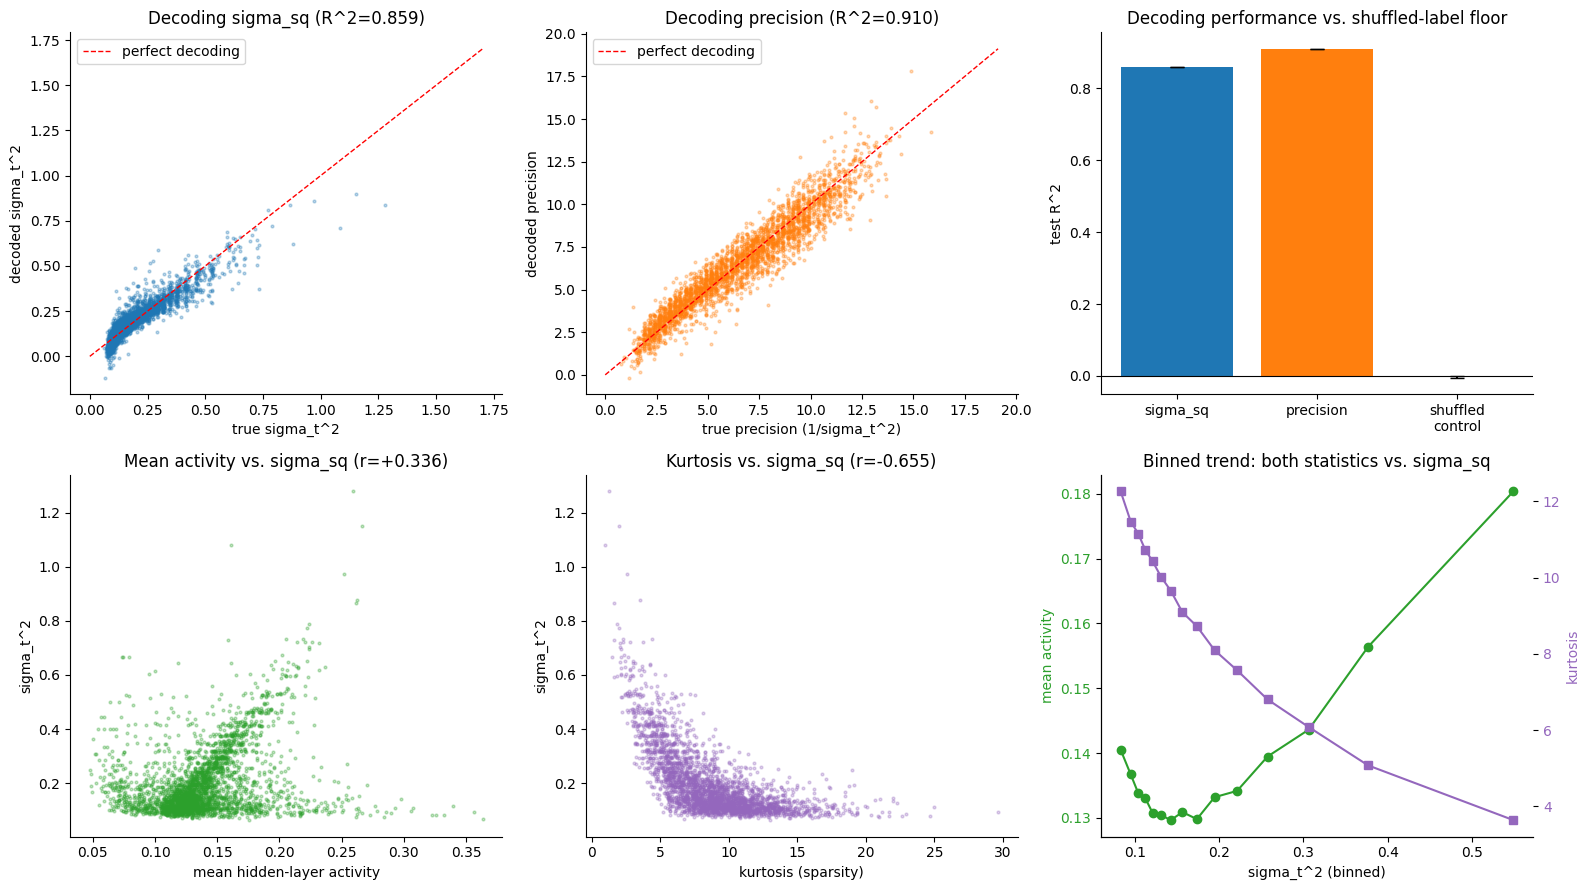


Saved decode_results.png


<Figure size 800x350 with 0 Axes>

In [50]:
%run decode.py

Trying network with batch=100.  
Using vectorized version of the files for speed purposes.

In [55]:
from paper_pytorch.task import KalmanFilteringTask
from train_vec import train

In [56]:
result = train(batch_size=100, max_iter=20000, save_path="kalman_checkpoints/kf_allgains_100.pt")


Batch #0; Frac. RMSE: 4.766254; Opt. RMSE: 0.439837; Net. RMSE: 2.536209
Batch #500; Frac. RMSE: 0.709634; Opt. RMSE: 0.453390; Net. RMSE: 0.775130
Batch #1000; Frac. RMSE: 0.200839; Opt. RMSE: 0.452952; Net. RMSE: 0.543923
Batch #1500; Frac. RMSE: 0.119376; Opt. RMSE: 0.453233; Net. RMSE: 0.507338
Batch #2000; Frac. RMSE: 0.080273; Opt. RMSE: 0.452350; Net. RMSE: 0.488661
Batch #2500; Frac. RMSE: 0.058543; Opt. RMSE: 0.452392; Net. RMSE: 0.478877
Batch #3000; Frac. RMSE: 0.047466; Opt. RMSE: 0.452502; Net. RMSE: 0.473980
Batch #3500; Frac. RMSE: 0.038120; Opt. RMSE: 0.452588; Net. RMSE: 0.469840
Batch #4000; Frac. RMSE: 0.031702; Opt. RMSE: 0.453959; Net. RMSE: 0.468350
Batch #4500; Frac. RMSE: 0.026696; Opt. RMSE: 0.452747; Net. RMSE: 0.464834
Batch #5000; Frac. RMSE: 0.023586; Opt. RMSE: 0.452820; Net. RMSE: 0.463500
Batch #5500; Frac. RMSE: 0.021712; Opt. RMSE: 0.453073; Net. RMSE: 0.462910
Batch #6000; Frac. RMSE: 0.016923; Opt. RMSE: 0.452913; Net. RMSE: 0.460577
Batch #6500; Fra

In [78]:
from collect_data import run
run(checkpoint_path="kalman_checkpoints/kf_allgains_100.pt", output_path="kf_dataset_batch100.pt");

Loaded trained network from kalman_checkpoints/kf_allgains_100.pt
Saved kf_dataset_batch100.pt
  train:    r_hid torch.Size([5000, 25, 200])
  test:     r_hid torch.Size([2000, 25, 200])


Pooled samples: train=125000, test=50000

1. LINEAR DECODING: sigma_sq vs. precision (1/sigma_sq)
  decode sigma_sq                R^2 = 0.9553
  decode precision (1/sigma_sq)  R^2 = 0.9857
  shuffled-label control         R^2 = 0.0021 +/- 0.0065  (range: [-0.0074, 0.0095])

  --> precision decodes better (0.9857 vs 0.9553)

2. SPECIFIC-STATISTIC CORRELATIONS (mean activity, sparsity/kurtosis)
  corr(mean activity, sigma_sq):  r=-0.0013  p=7.64e-01
  corr(kurtosis,      sigma_sq):  r=-0.6549  p=0.00e+00

  --> SPARSITY code looks dominant


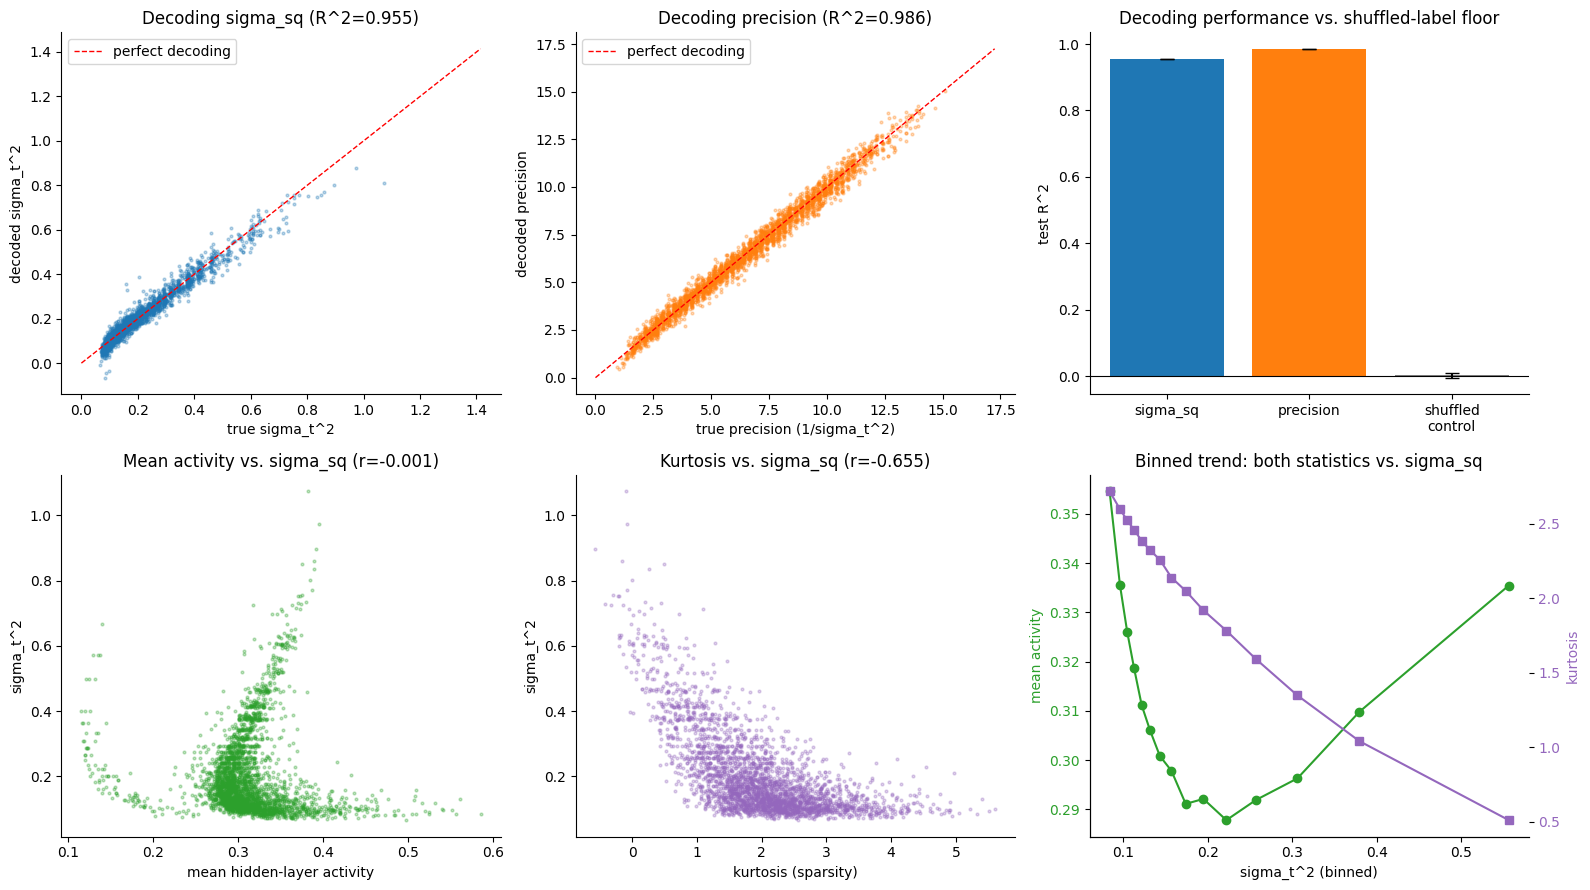


Saved decode_results.png


In [76]:
from decode import lin_decoder
data = lin_decoder("kf_dataset_batch100.pt")

In [77]:
import torch
checkpoint = torch.load("kalman_checkpoints/kf_allgains_100.pt", map_location="cpu", weights_only=False)
net = KalmanRNN(n_in=checkpoint["config"]["n_in"], n_hid=checkpoint["config"]["n_hid"], n_out=1)
net.load_state_dict(checkpoint["state_dict"])
net.eval()

test_task = KalmanFilteringTask(batch_size=2000, tr_cond="all_gains", seed=999)
batch = test_task.sample(include_internals=True)

with torch.no_grad():
    y_hat = net(batch.input)  # (batch, T, 1)

rmse_net = torch.sqrt(torch.mean((y_hat - batch.target) ** 2)).item()
rmse_opt = torch.sqrt(torch.mean((batch.opt_mean - batch.target) ** 2)).item()
frac_rmse = 100 * (rmse_net - rmse_opt) / rmse_opt

print(f"Net RMSE:        {rmse_net:.4f}")
print(f"Optimal RMSE:    {rmse_opt:.4f}")
print(f"Fractional RMSE: {frac_rmse:.2f}%")

Net RMSE:        0.4558
Optimal RMSE:    0.4527
Fractional RMSE: 0.68%
